In [47]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### TEST FINALE
    

In [48]:
# 1. Librerie per la manipolazione e l'analisi dei dati
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 2. Librerie per i grafici e la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Componenti specifici di Scikit-Learn per l'IA (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

### ANALISI ESPLORATIVA

#### CARICAMENTO DATI ED INFORMAZIONI SUL DATASET

In [49]:
df = pd.read_csv('music_genre.csv')  
df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [50]:
print("Dimensioni iniziali del dataset:")
print(df.shape)
df.info()


Dimensioni iniziali del dataset:
(50005, 18)
<class 'pandas.DataFrame'>
RangeIndex: 50005 entries, 0 to 50004
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   instance_id       50000 non-null  float64
 1   artist_name       50000 non-null  str    
 2   track_name        50000 non-null  str    
 3   popularity        50000 non-null  float64
 4   acousticness      50000 non-null  float64
 5   danceability      50000 non-null  float64
 6   duration_ms       50000 non-null  float64
 7   energy            50000 non-null  float64
 8   instrumentalness  50000 non-null  float64
 9   key               50000 non-null  str    
 10  liveness          50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  mode              50000 non-null  str    
 13  speechiness       50000 non-null  float64
 14  tempo             50000 non-null  str    
 15  obtained_date     50000 non-null  str    
 16  valenc

In [51]:
print("\nValori mancanti per colonna:")
display(df.isnull().sum())


Valori mancanti per colonna:


instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

#### PULIZIA DATI

In [52]:
# Sostituiamo i valori mancanti rappresentati da "?" con NaN.
df.replace("?", np.nan, inplace=True)

# Convertiamo forzatamente in formato numerico decimale (float).
df["tempo"] = pd.to_numeric(df["tempo"])

# Rimuoviamo le righe con valori mancanti
df.dropna(inplace=True)

# Rimuoviamo eventuali righe identiche salvate per errore nel file CSV per non falsare i modelli.
df.drop_duplicates(inplace=True)

# 'instance_id': un semplice indice numerico del database senza valore musicale.
# 'obtained_date': la data di scaricamento dei dati , inutile per gli obiettivi del progetto.

colonne_inutili = ["instance_id", "obtained_date"]

# Eseguiamo la rimozione fisica dal dataset
df.drop(columns=colonne_inutili, inplace=True)



df.head()


,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
2,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
3,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
4,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic


##### Sono stati sostituiti i punti interrogativi con valori NaN.
##### La colonna tempo è stata convertita in numerica.
##### Sono state eliminate righe con valori mancanti e duplicati.
##### Le colonne instance_id e obtained_date sono state rimosse perché non utili alla classificazione musicale.

#### GRAFICI INIZIALI


##### STILE GRAFICI


In [53]:
sns.set_theme(style="whitegrid", context="notebook")

colore_viola = "#6C63FF"
colore_rosso = "#FF6B6B"
colore_verde = "#4ECDC4"
colore_giallo = "#6A4B03"
colore_blu = "#118AB2"

##### DISTRIBUZIONE GENERI MUSICALI

C:\Users\lunaz\AppData\Local\Temp\ipykernel_18720\5340539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


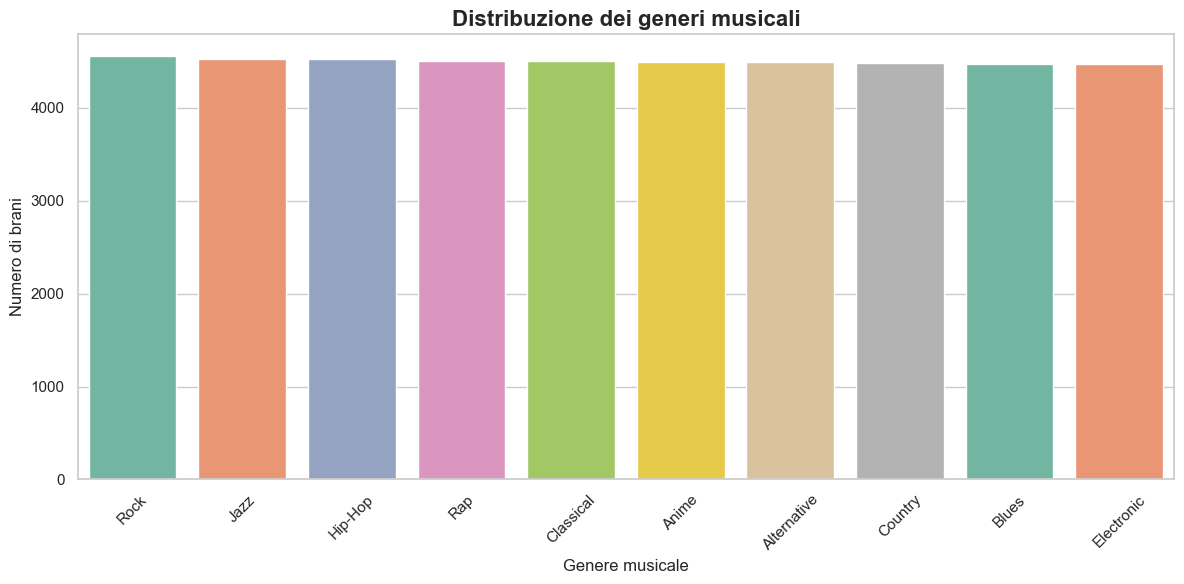

In [54]:
plt.figure(figsize=(12, 6))

ordine_generi = df["music_genre"].value_counts().index
palette_generi = sns.color_palette("Set2", n_colors=df["music_genre"].nunique())

sns.countplot(
    data=df,
    x="music_genre",
    order=ordine_generi,
    palette=palette_generi
)

plt.title("Distribuzione dei generi musicali", fontsize=16, fontweight="bold")
plt.xlabel("Genere musicale")
plt.ylabel("Numero di brani")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### I generi musicali risultano abbastanza bilanciati. 
##### Questo è positivo perché il modello non viene troppo influenzato da un genere molto più presente degli altri.


##### POPULARITY

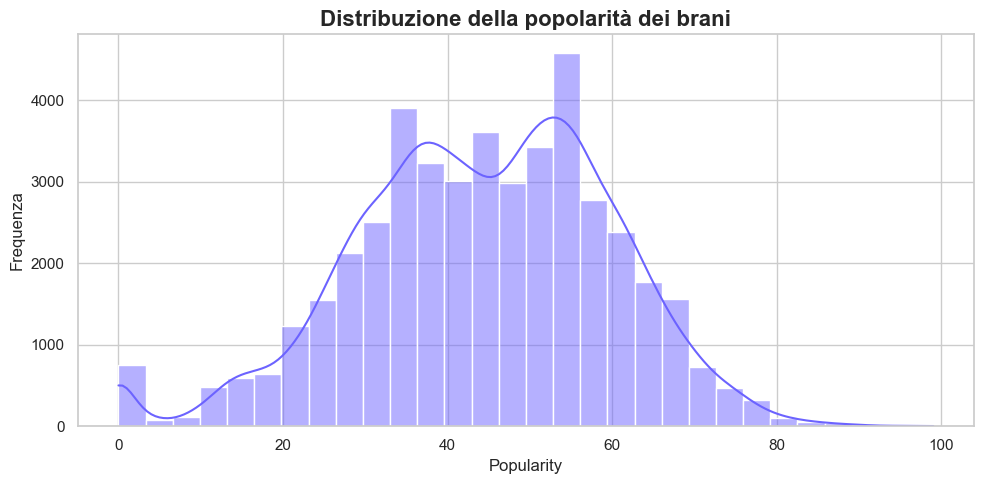

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True,
    color=colore_viola
)

plt.title("Distribuzione della popolarità dei brani", fontsize=16, fontweight="bold")
plt.xlabel("Popularity")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani hanno una popolarità medio-bassa.
##### Sono meno frequenti i brani con valori di popolarità molto alti.

#### ENERGY

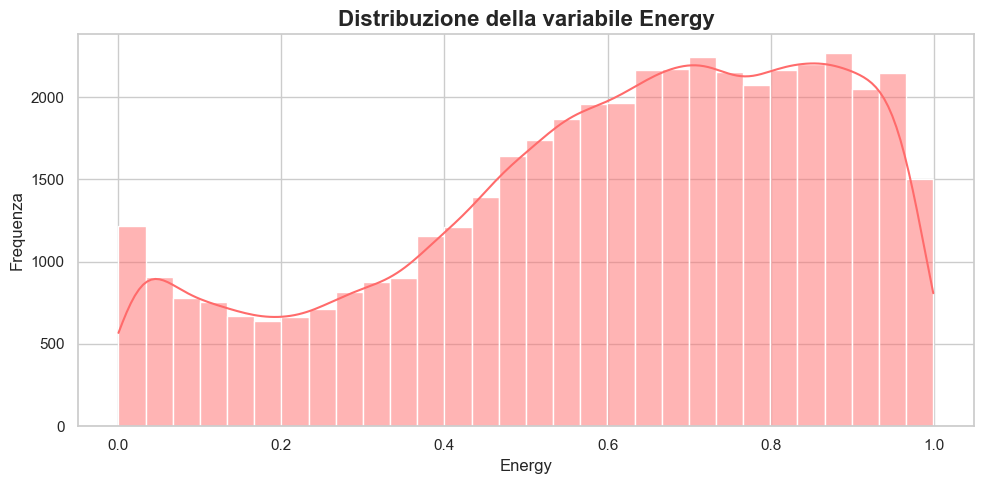

In [56]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["energy"],
    bins=30,
    kde=True,
    color=colore_rosso
)

plt.title("Distribuzione della variabile Energy", fontsize=16, fontweight="bold")
plt.xlabel("Energy")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani presentano valori medio-alti di energy.
##### Questa variabile può essere utile per distinguere generi più intensi da generi più tranquilli.


##### DANCEABILITY

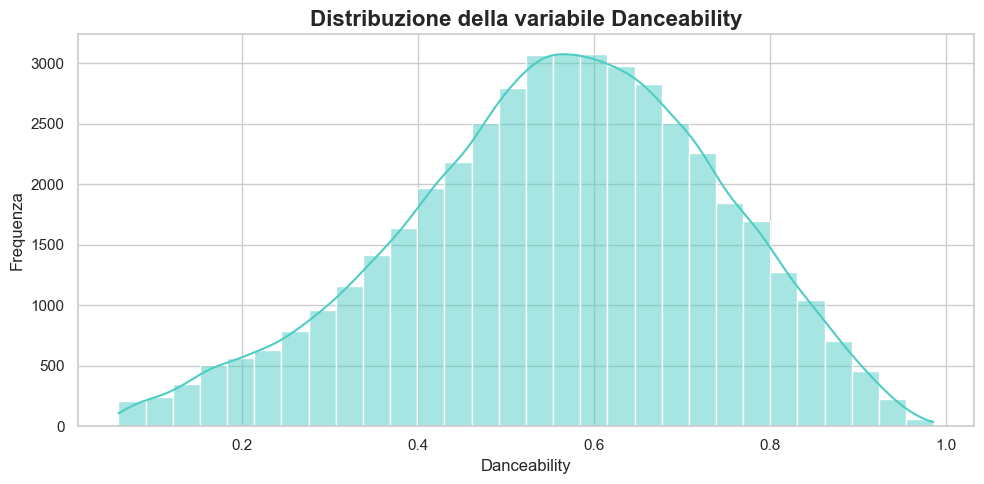

In [57]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["danceability"],
    bins=30,
    kde=True,
    color=colore_verde
)

plt.title("Distribuzione della variabile Danceability", fontsize=16, fontweight="bold")
plt.xlabel("Danceability")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### La danceability si concentra soprattutto su valori intermedi.
##### Può aiutare a distinguere generi più ballabili da generi meno ritmici.

##### ACOUSTICNESS


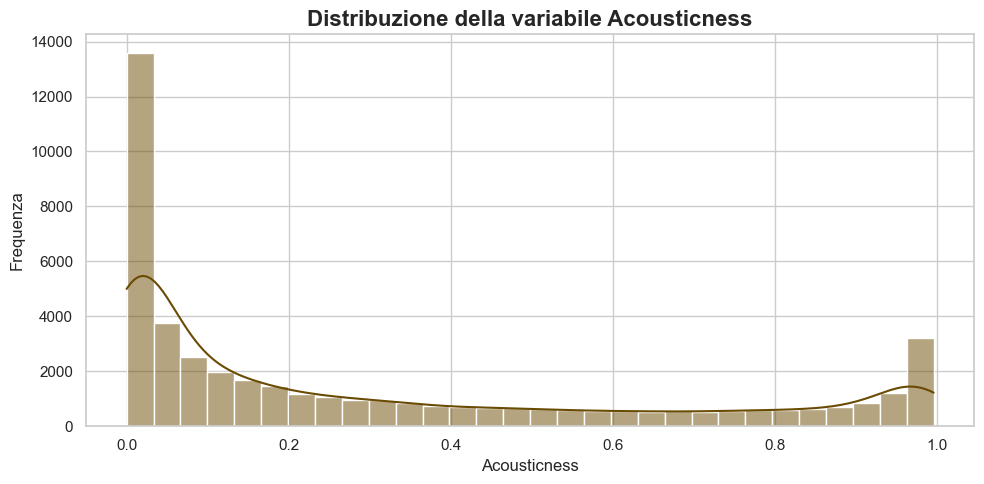

In [58]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["acousticness"],
    bins=30,
    kde=True,
    color=colore_giallo
)

plt.title("Distribuzione della variabile Acousticness", fontsize=16, fontweight="bold")
plt.xlabel("Acousticness")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

##### Molti brani hanno valori bassi di acousticness.
##### Questo indica che diversi brani sono poco acustici e più legati a suoni prodotti o elettronici.

##### HEATMAP CORRELAZIONI

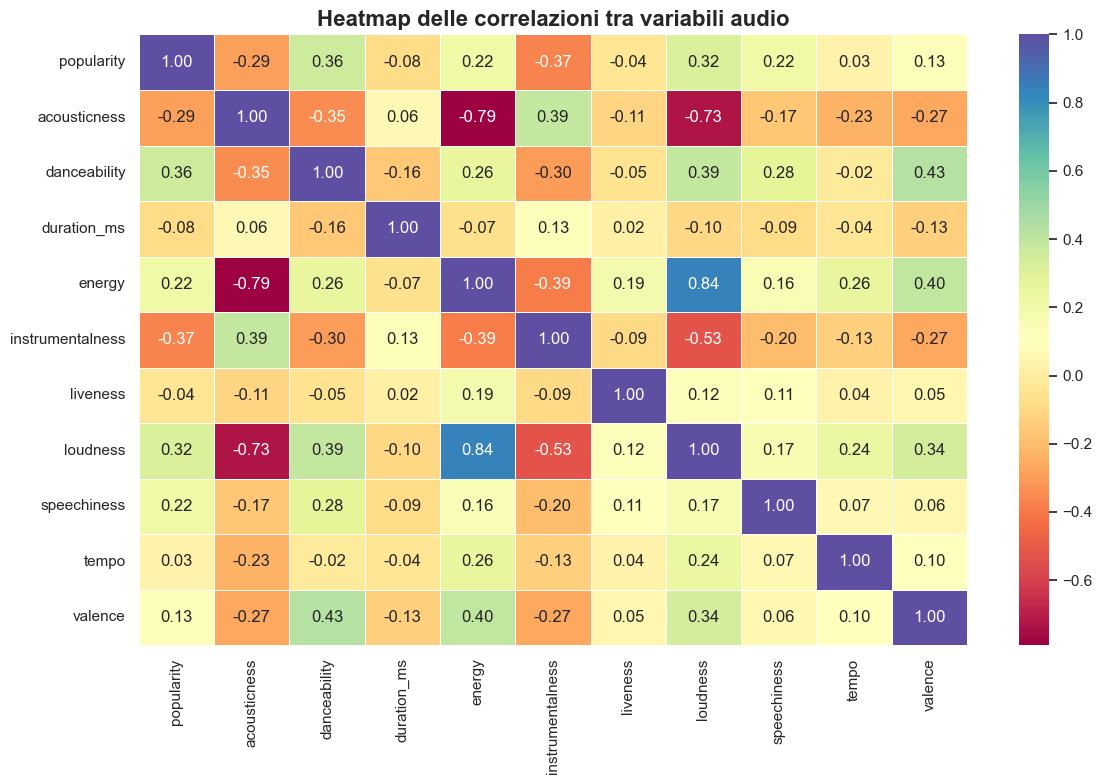

In [59]:
colonne_numeriche = [
    "popularity",
    "acousticness",
    "danceability",
    "duration_ms",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[colonne_numeriche].corr(),
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap delle correlazioni tra variabili audio", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

##### Energy e loudness risultano collegate tra loro.
##### Questo è coerente perché i brani più energici tendono spesso ad avere anche un volume percepito più alto.

#### STATISTICHE INIZIALI DOPO LA PULIZIA DEI DATI

In [60]:
print("Statistiche descrittive:")
display(df.describe())

print("Distribuzione dei generi musicali:")
display(df["music_genre"].value_counts())


Statistiche descrittive:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,45020.000000,45020.000000,45020.000000,4.502000e+04,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000,45020.000000
mean,44.263327,0.306596,0.558532,2.211695e+05,0.599553,0.181843,0.193951,-9.137016,0.093783,119.952961,0.456394
std,15.553972,0.341391,0.178858,1.276884e+05,0.264510,0.325847,0.161715,6.156400,0.101469,30.641701,0.247161
min,0.000000,0.000000,0.059600,-1.000000e+00,0.000792,0.000000,0.009670,-47.046000,0.022300,34.347000,0.000000
25%,34.000000,0.020100,0.442000,1.747230e+05,0.432000,0.000000,0.096900,-10.860000,0.036100,94.941500,0.257000
50%,45.000000,0.145000,0.568000,2.194385e+05,0.642000,0.000159,0.126000,-7.284000,0.048900,119.879000,0.448000
75%,56.000000,0.551000,0.687000,2.686400e+05,0.815250,0.154000,0.244000,-5.177000,0.098800,140.471250,0.648000
max,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,1.000000,3.744000,0.942000,220.276000,0.992000


Distribuzione dei generi musicali:


music_genre
Rock           4561
Jazz           4521
Hip-Hop        4520
Rap            4504
Classical      4500
Anime          4497
Alternative    4495
Country        4486
Blues          4470
Electronic     4466
Name: count, dtype: int64

#### GRAFICO STATISTICHE INIZIALI

#### BOXPLOT

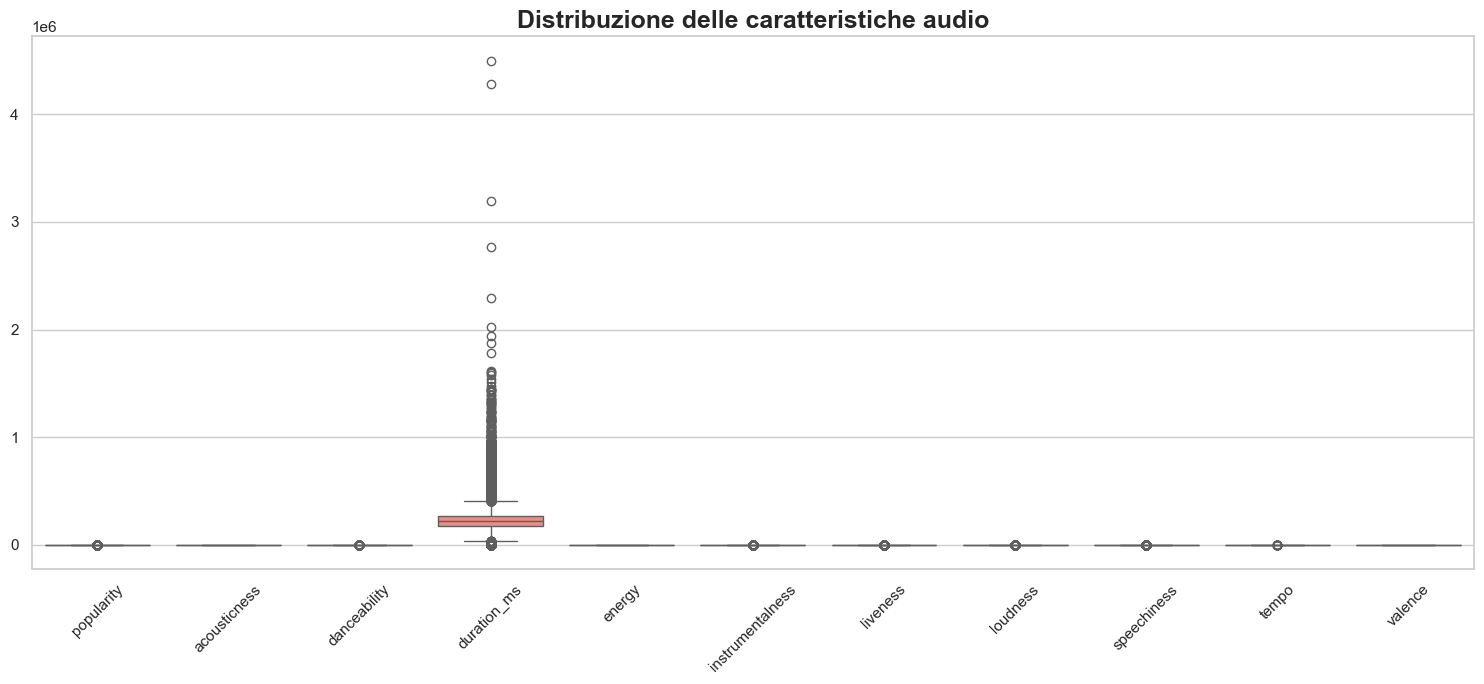

In [61]:
plt.figure(figsize=(15,7))

sns.boxplot(
    data=df[colonne_numeriche],
    palette="Set3"
)

plt.title(
    "Distribuzione delle caratteristiche audio",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Il boxplot evidenzia la presenza di differenti distribuzioni tra le variabili audio. Alcune caratteristiche presentano una dispersione elevata e numerosi outlier, suggerendo una forte eterogeneità tra i brani. Questo potrebbe favorire la capacità dei modelli di distinguere i generi musicali.

#### GESTIONE DURATION_MS

In [62]:
df['duration_ms'].describe()

count    4.502000e+04
mean     2.211695e+05
std      1.276884e+05
min     -1.000000e+00
25%      1.747230e+05
50%      2.194385e+05
75%      2.686400e+05
max      4.497994e+06
Name: duration_ms, dtype: float64

In [63]:
(df['duration_ms'] == -1).sum()

np.int64(4460)

In [64]:
df['duration_ms'] = df['duration_ms'].replace(-1, np.nan)

In [65]:
df['duration_ms'].isna().sum()

np.int64(4460)

In [66]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

df['duration_ms'] = imputer.fit_transform(
    df[['duration_ms']]
)

In [67]:
df['duration_ms'].describe()

count    4.502000e+04
mean     2.437106e+05
std      1.046619e+05
min      1.550900e+04
25%      1.949330e+05
50%      2.275330e+05
75%      2.686400e+05
max      4.497994e+06
Name: duration_ms, dtype: float64

In [68]:
df['duration_log'] = np.log1p(df['duration_ms'])

##### La variabile duration_ms conteneva 4460 osservazioni con valore -1, interpretate come valori mancanti e non come durate valide. Tali valori sono stati sostituiti con NaN e successivamente imputati utilizzando la mediana della distribuzione. Per ridurre l'asimmetria e l'influenza dei valori estremi, è stata poi applicata una trasformazione logaritmica (log1p).

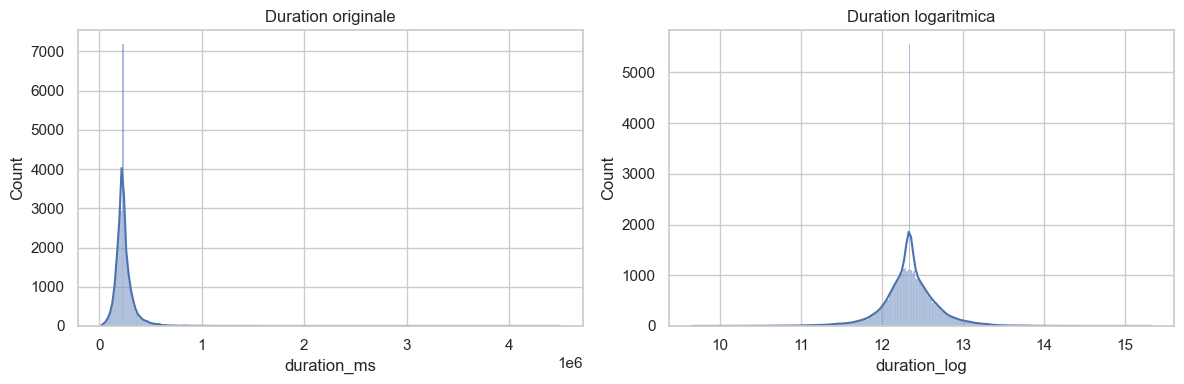

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['duration_ms'], kde=True, ax=ax[0])
ax[0].set_title('Duration originale')

sns.histplot(df['duration_log'], kde=True, ax=ax[1])
ax[1].set_title('Duration logaritmica')

plt.tight_layout()
plt.show()

##### La variabile duration_ms presentava una forte asimmetria positiva dovuta alla presenza di brani particolarmente lunghi. Per ridurre l'influenza dei valori estremi e ottenere una distribuzione più regolare, è stata applicata una trasformazione logaritmica (log1p), ottenendo la nuova variabile duration_log.

In [70]:
df.drop('duration_ms', axis=1, inplace=True)

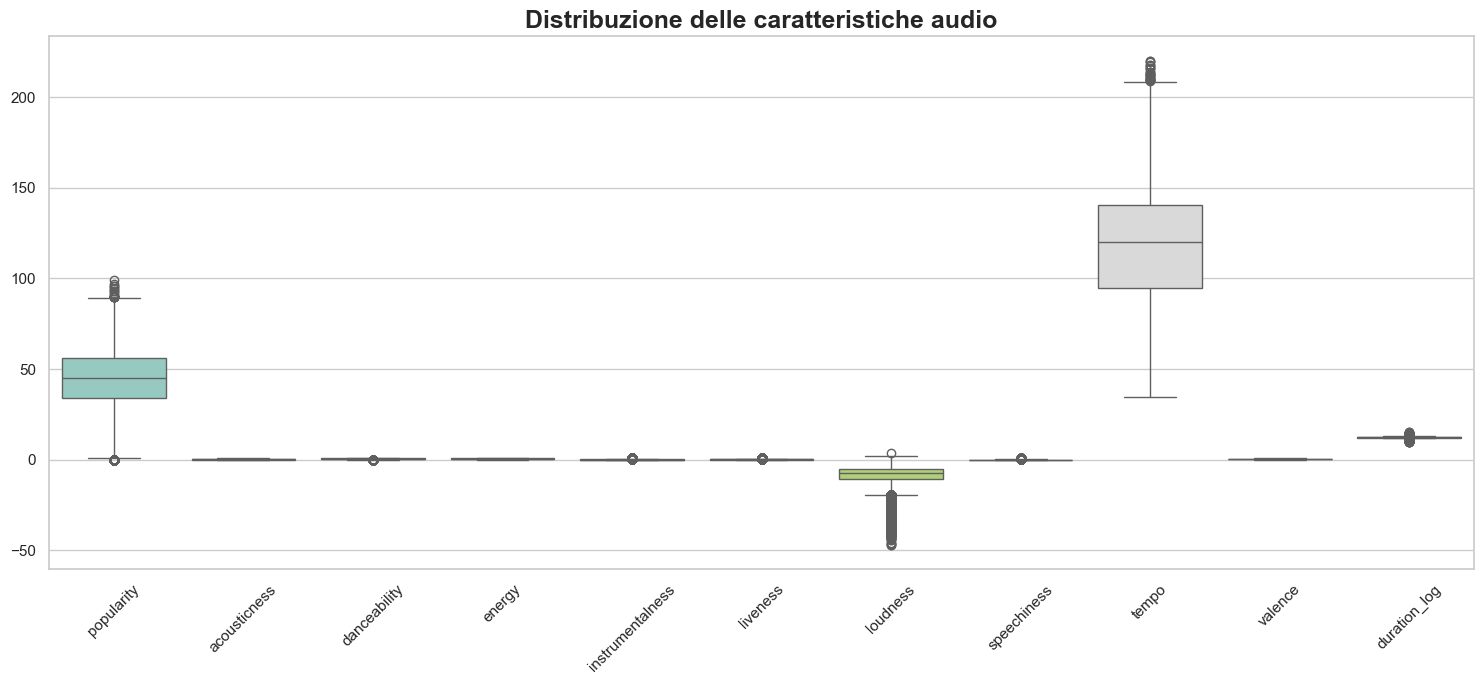

In [71]:
colonne_numeriche = [
    'popularity',
    'acousticness',
    'danceability',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'valence',
    'duration_log'
]

plt.figure(figsize=(15,7))

sns.boxplot(
    data=df[colonne_numeriche],
    palette="Set3"
)

plt.title(
    "Distribuzione delle caratteristiche audio",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### GESTIONE ALTRE VARIABILI

##### VARIABILE LOUDNESS

In [72]:
df["loudness"].describe()

count    45020.000000
mean        -9.137016
std          6.156400
min        -47.046000
25%        -10.860000
50%         -7.284000
75%         -5.177000
max          3.744000
Name: loudness, dtype: float64

In [73]:
df.loc[df["loudness"] > 0, "loudness"] = np.nan
df["loudness"].isna().sum()


np.int64(42)

In [74]:
df.dropna(subset=["loudness"], inplace=True)
df["loudness"].describe()

count    44978.000000
mean        -9.146169
std          6.151940
min        -47.046000
25%        -10.863000
50%         -7.288000
75%         -5.181000
max          0.000000
Name: loudness, dtype: float64

#####  Attraverso l'estrazione della tabella dei percentili con .describe(), è stato isolato un comportamento anomalo nel valore massimo (max = 0.0 o superiore). Nella scala dei decibel digitali (dBFS) utilizzata nelle piattaforme di streaming, lo zero assoluto o i valori positivi indicano distorsione digitale distruttiva o, più frequentemente, record audio corrotti o fallimenti nel campionamento dell'algoritmo. Non configurandosi come outliers acustici naturali (tracce volutamente ad alto volume), questi valori sentinella sono stati rimossi. Il confronto tra il .describe() iniziale e finale dimostra il ripristino di una distribuzione coerente e centrata sui reali standard industriali. Verifichiamo che il valore 'max' sia rientrato nei parametri fisici corretti della piattaforma (< 0)

#### VARIABILI DA ELIMINARE

In [75]:
df = df.drop(
    columns=[
        'track_name',
        'mode',
        'key'
    ],
    errors='ignore'
)


In [76]:
df.head()

,artist_name,popularity,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,music_genre,duration_log
0,Röyksopp,27.0,0.00468,0.652,0.941,0.79200,0.115,-5.201,0.0748,100.889,0.759,Electronic,12.335055
1,Thievery Corporation,31.0,0.01270,0.622,0.890,0.95000,0.124,-7.043,0.0300,115.002,0.531,Electronic,12.293598
2,Dillon Francis,28.0,0.00306,0.620,0.755,0.01180,0.534,-4.617,0.0345,127.994,0.333,Electronic,12.281245
3,Dubloadz,34.0,0.02540,0.774,0.700,0.00253,0.157,-4.498,0.2390,128.014,0.270,Electronic,12.025006
4,What So Not,32.0,0.00465,0.638,0.587,0.90900,0.157,-6.266,0.0413,145.036,0.323,Electronic,12.312098


#### ENCODING DI MUSIC_GENRE

In [77]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["music_genre_encoded"] = label_encoder.fit_transform(
    df["music_genre"]
)

generi = label_encoder.classes_

print("Generi musicali:")
for i, genere in enumerate(generi):
    print(i, "=", genere)


Generi musicali:
0 = Alternative
1 = Anime
2 = Blues
3 = Classical
4 = Country
5 = Electronic
6 = Hip-Hop
7 = Jazz
8 = Rap
9 = Rock


##### SPLIT IN TEST E TARGET

In [78]:
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=["music_genre", "music_genre_encoded"]
)

y = df["music_genre_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


#### FEATURE ENGINEERING SU ARTIST_NAME

In [79]:

train_artist = pd.DataFrame({
    "artist_name": X_train["artist_name"].astype(str),
    "music_genre_encoded": y_train
})

# Conteggio di quante volte compare ogni artista nel training
artist_count = train_artist["artist_name"].value_counts()

X_train["artist_count"] = X_train["artist_name"].map(artist_count).fillna(0)
X_test["artist_count"] = X_test["artist_name"].map(artist_count).fillna(0)

# Probabilità globale dei generi
global_probs = y_train.value_counts(normalize=True).sort_index()

# Tabella artista x genere
artist_genre_counts = pd.crosstab(
    train_artist["artist_name"],
    train_artist["music_genre_encoded"]
)

# Smoothing per evitare valori troppo estremi
alpha = 10

artist_genre_probs = artist_genre_counts.copy()

for classe in range(len(generi)):
    if classe not in artist_genre_probs.columns:
        artist_genre_probs[classe] = 0

artist_genre_probs = artist_genre_probs.sort_index(axis=1)

artist_totals = artist_genre_probs.sum(axis=1)

for classe in range(len(generi)):
    artist_genre_probs[classe] = (
        artist_genre_probs[classe] + alpha * global_probs.get(classe, 0)
    ) / (artist_totals + alpha)

# Aggiungo una probabilità per ogni genere
for classe, genere in enumerate(generi):
    nome_colonna = f"artist_prob_{genere}"

    X_train[nome_colonna] = X_train["artist_name"].map(
        artist_genre_probs[classe]
    ).fillna(global_probs.get(classe, 0))

    X_test[nome_colonna] = X_test["artist_name"].map(
        artist_genre_probs[classe]
    ).fillna(global_probs.get(classe, 0))

# Ora rimuovo artist_name testuale
X_train.drop(columns=["artist_name"], errors="ignore", inplace=True)
X_test.drop(columns=["artist_name"], errors="ignore", inplace=True)

print("Feature create da artist_name:")
print([col for col in X_train.columns if "artist_" in col])


Feature create da artist_name:
['artist_count', 'artist_prob_Alternative', 'artist_prob_Anime', 'artist_prob_Blues', 'artist_prob_Classical', 'artist_prob_Country', 'artist_prob_Electronic', 'artist_prob_Hip-Hop', 'artist_prob_Jazz', 'artist_prob_Rap', 'artist_prob_Rock']


##### La variabile artist_name è stata inserita non direttamente come testo.
##### Da artist_name sono state create feature numeriche più informative:
##### - artist_count: quante volte compare un artista nel training set;
##### - artist_prob_genere: probabilità che un artista sia associato a ciascun genere.
##### Questa strategia aumenta l'accuracy perché molti artisti sono fortemente legati a specifici generi musicali.

In [80]:
from sklearn.impute import SimpleImputer



imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape train:", X_train_scaled.shape)
print("Shape test:", X_test_scaled.shape)

Shape train: (35982, 22)
Shape test: (8996, 22)


#### ADDESTRAMENTO MODELLI

In [ ]:
from sklearn.tree import DecisionTreeClassifier

modelli = {
    "Decision Tree": DecisionTreeClassifier(
    max_depth=20,
    random_state=42
    ),
    
    
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )
}



risultati = {}

for nome, modello in modelli.items():
    print(f"\nAddestramento modello: {nome}")

    modello.fit(X_train_scaled, y_train)

    predizioni = modello.predict(X_test_scaled)

    acc = accuracy_score(y_test, predizioni)

    risultati[nome] = acc

    print(f"Accuracy {nome}: {acc:.2%}")

risultati_df = pd.DataFrame({
    "Modello": risultati.keys(),
    "Accuracy": risultati.values()
}).sort_values("Accuracy", ascending=False)

display(risultati_df)


Addestramento modello: Decision Tree
Accuracy Decision Tree: 74.98%

Addestramento modello: Random Forest
Accuracy Random Forest: 75.64%

Addestramento modello: LightGBM


#### GRAFICO ACCURACY

C:\Users\lunaz\AppData\Local\Temp\ipykernel_18720\378411904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


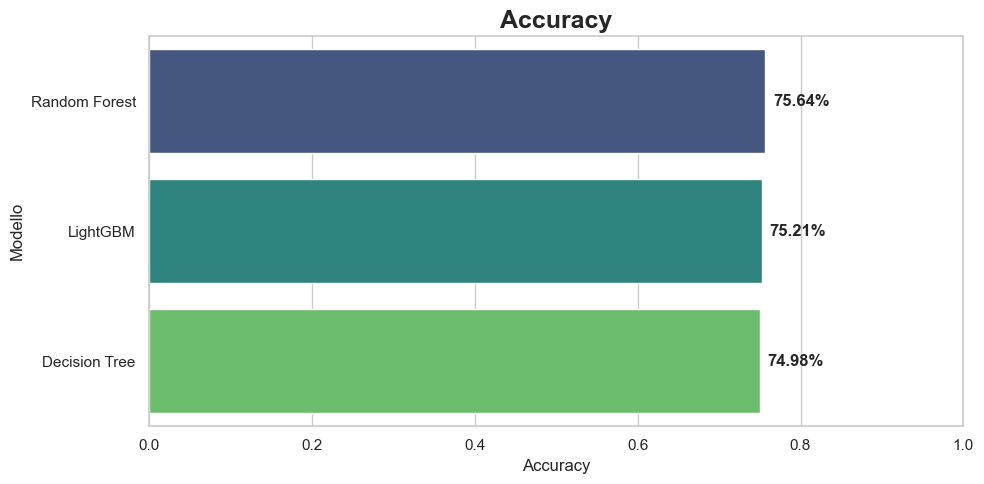

In [ ]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=risultati_df,
    x="Accuracy",
    y="Modello",
    palette="viridis"
)

plt.title(
    "Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Accuracy")
plt.ylabel("Modello")
plt.xlim(0, 1)

for i, valore in enumerate(risultati_df["Accuracy"]):
    plt.text(
        valore + 0.01,
        i,
        f"{valore:.2%}",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


#### REPORT MIGLIOR MODELLO

Miglior modello: Random Forest
              precision    recall  f1-score   support

 Alternative       0.67      0.64      0.65       899
       Anime       0.96      0.98      0.97       896
       Blues       0.83      0.88      0.86       894
   Classical       0.95      0.97      0.96       900
     Country       0.84      0.86      0.85       897
  Electronic       0.87      0.91      0.89       889
     Hip-Hop       0.48      0.49      0.48       904
        Jazz       0.85      0.78      0.82       904
         Rap       0.43      0.41      0.42       901
        Rock       0.67      0.64      0.65       912

    accuracy                           0.76      8996
   macro avg       0.75      0.76      0.76      8996
weighted avg       0.75      0.76      0.75      8996



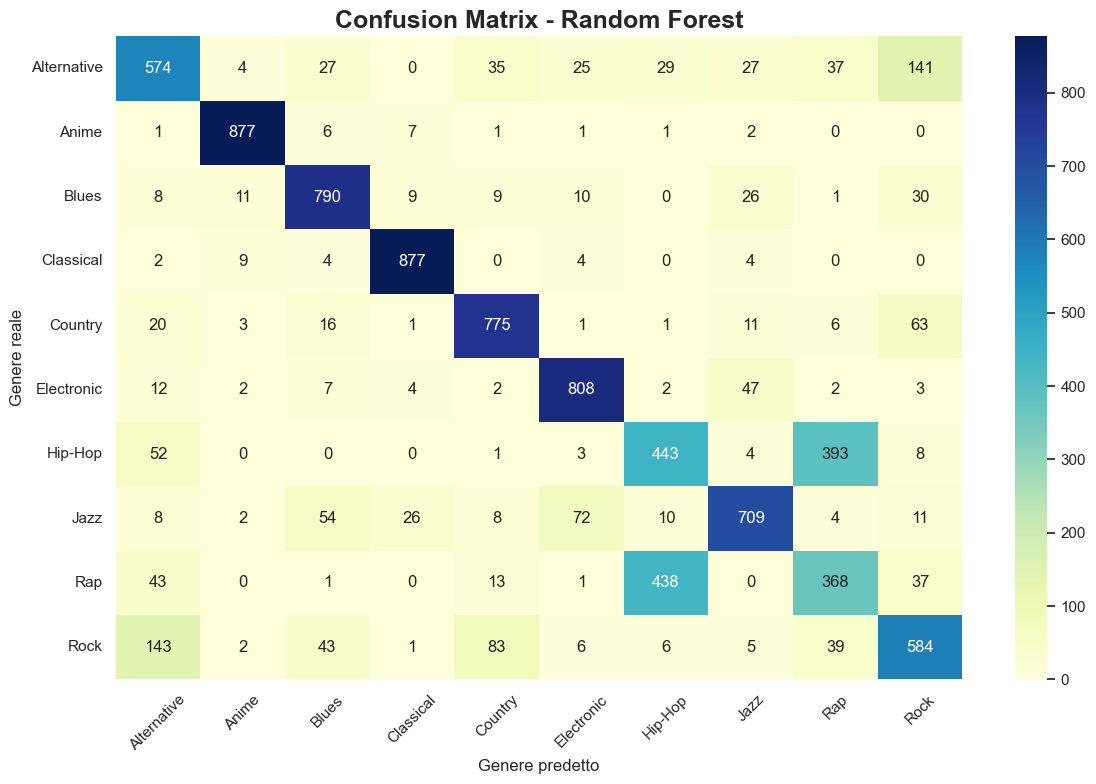

In [ ]:

miglior_modello_nome = risultati_df.iloc[0]["Modello"]
miglior_modello = modelli[miglior_modello_nome]

y_pred_best = miglior_modello.predict(X_test_scaled)

print("Miglior modello:", miglior_modello_nome)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))




cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {miglior_modello_nome}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Genere predetto")
plt.ylabel("Genere reale")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()




#### OTTIMIZZAZIONE DEL LIGHTGBM CON OPTUNA

In [ ]:
import optuna
from sklearn.metrics import accuracy_score
import lightgbm as lgb

In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "random_state": 42,
        "verbosity": -1
    }

    model = lgb.LGBMClassifier(**params)

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    return accuracy_score(y_test, pred)

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30)

print("Migliori parametri:")
print(study.best_params)

print(f"\nMiglior accuracy: {study.best_value:.2%}")

[I 2026-06-05 15:57:13,822] A new study created in memory with name: no-name-dc8e4ece-9957-4b04-917b-9b0b98abc756
[I 2026-06-05 15:57:28,079] Trial 0 finished with value: 0.7508892841262783 and parameters: {'n_estimators': 528, 'learning_rate': 0.053683938361300636, 'num_leaves': 63, 'max_depth': 6, 'subsample': 0.8855575329438596, 'colsample_bytree': 0.898433030295748, 'min_child_samples': 28}. Best is trial 0 with value: 0.7508892841262783.
[I 2026-06-05 15:57:31,682] Trial 1 finished with value: 0.7553357047576701 and parameters: {'n_estimators': 134, 'learning_rate': 0.06132415782712157, 'num_leaves': 68, 'max_depth': 10, 'subsample': 0.9492103357187215, 'colsample_bytree': 0.7032380262491693, 'min_child_samples': 39}. Best is trial 1 with value: 0.7553357047576701.
[I 2026-06-05 15:57:35,111] Trial 2 finished with value: 0.759115162294353 and parameters: {'n_estimators': 226, 'learning_rate': 0.08854549450200337, 'num_leaves': 31, 'max_depth': 5, 'subsample': 0.8774548308380423, '

Migliori parametri:
{'n_estimators': 705, 'learning_rate': 0.010272724021088999, 'num_leaves': 26, 'max_depth': 3, 'subsample': 0.7829410214552366, 'colsample_bytree': 0.617037875024761, 'min_child_samples': 11}

Miglior accuracy: 78.28%


In [ ]:
best_model = lgb.LGBMClassifier(
    **study.best_params,
    random_state=42,
    verbosity=-1
)

best_model.fit(X_train_scaled, y_train)

y_pred_optuna = best_model.predict(X_test_scaled)

accuracy_optuna = accuracy_score(y_test, y_pred_optuna)

print(f"Accuracy finale dopo Optuna: {accuracy_optuna:.2%}")

Accuracy finale dopo Optuna: 78.28%


#### OTTIMIZZAZIONE DEL RANDOM FOREST CON OPTUNA

In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, pred)

    return accuracy

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=30
)

print("Migliori parametri:")
print(study.best_params)

print(f"Miglior accuracy: {study.best_value:.2%}")

[I 2026-06-05 16:02:15,166] A new study created in memory with name: no-name-daca1d11-3817-4a53-9e42-a9ed5abfaff6
[I 2026-06-05 16:02:20,163] Trial 0 finished with value: 0.7726767452200978 and parameters: {'n_estimators': 309, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7726767452200978.
[I 2026-06-05 16:02:24,672] Trial 1 finished with value: 0.7712316585148955 and parameters: {'n_estimators': 285, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.7726767452200978.
[I 2026-06-05 16:02:31,661] Trial 2 finished with value: 0.7730102267674522 and parameters: {'n_estimators': 498, 'max_depth': 39, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 2 with value: 0.7730102267674522.
[I 2026-06-05 16:02:34,738] Trial 3 finished with value: 0.7664517563361494 and parameters: {'n_estimators': 211, 'max_depth': 47,

Migliori parametri:
{'n_estimators': 394, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2'}
Miglior accuracy: 77.92%


In [ ]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_scaled, y_train)

y_pred_rf_optuna = best_rf.predict(X_test_scaled)

accuracy_rf_optuna = accuracy_score(
    y_test,
    y_pred_rf_optuna
)

print(
    f"Accuracy finale Random Forest dopo Optuna: {accuracy_rf_optuna:.2%}"
)

Accuracy finale Random Forest dopo Optuna: 77.92%


#### OTTIMIZZAZIONE DEL DECISION TREE CON OPTUNA

In [ ]:
def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),
        "random_state": 42
    }

    model = DecisionTreeClassifier(**params)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    return accuracy


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("Migliori parametri trovati:")
print(study.best_params)

print(f"Miglior accuracy Decision Tree con Optuna: {study.best_value:.2%}")

[I 2026-06-05 16:04:17,607] A new study created in memory with name: no-name-0247e38f-7ae4-4b36-afed-9dbbcd28626d
[I 2026-06-05 16:04:18,299] Trial 0 finished with value: 0.7438861716318363 and parameters: {'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 5, 'criterion': 'log_loss'}. Best is trial 0 with value: 0.7438861716318363.
[I 2026-06-05 16:04:18,898] Trial 1 finished with value: 0.7646731880835927 and parameters: {'max_depth': 13, 'min_samples_split': 29, 'min_samples_leaf': 1, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.7646731880835927.
[I 2026-06-05 16:04:19,522] Trial 2 finished with value: 0.7644508670520231 and parameters: {'max_depth': 28, 'min_samples_split': 11, 'min_samples_leaf': 18, 'criterion': 'entropy'}. Best is trial 1 with value: 0.7646731880835927.
[I 2026-06-05 16:04:20,091] Trial 3 finished with value: 0.7607825700311249 and parameters: {'max_depth': 18, 'min_samples_split': 26, 'min_samples_leaf': 12, 'criterion': 'gini'}. Best is t

Migliori parametri trovati:
{'max_depth': 12, 'min_samples_split': 25, 'min_samples_leaf': 17, 'criterion': 'log_loss'}
Miglior accuracy Decision Tree con Optuna: 77.07%


In [ ]:
best_tree = DecisionTreeClassifier(
    **study.best_params,
    random_state=42
)

best_tree.fit(X_train_scaled, y_train)

y_pred_tree_optuna = best_tree.predict(X_test_scaled)

accuracy_tree_optuna = accuracy_score(
    y_test,
    y_pred_tree_optuna
)

print(
    f"Accuracy finale Decision Tree dopo Optuna: {accuracy_tree_optuna:.2%}"
)

Accuracy finale Decision Tree dopo Optuna: 77.07%


#### RISULTATI DELL'OTTIMIZZAZIONE CON OPTUNA

In [ ]:

print(f"Decision Tree Optuna: {accuracy_tree_optuna:.2%}")


print(f"Random Forest Optuna: {accuracy_rf_optuna:.2%}")


print(f"LightGBM Optuna: {accuracy_optuna:.2%}")

Decision Tree Optuna: 77.07%
Random Forest Optuna: 77.92%
LightGBM Optuna: 78.28%


In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Pulizia preventiva dello storico artisti
df_clean = df.dropna(subset=['artist_name', 'music_genre']).copy()
df_clean['artist_name_lower'] = df_clean['artist_name'].astype(str).str.strip().str.lower()

# Generazione dei dizionari per l'app
artist_counts = df_clean['artist_name_lower'].value_counts().to_dict()

artist_genre_map = {}
for artist, group in df_clean.groupby('artist_name_lower'):
    total_tracks = len(group)
    genre_counts = group['music_genre'].value_counts()
    if not genre_counts.empty:
        top_genre = genre_counts.idxmax()
        top_genre_count = genre_counts.max()
        artist_genre_map[artist] = {
            "genre": str(top_genre),
            "count": int(top_genre_count),
            "total": int(total_tracks)
        }

artist_genre_history = df_clean[['artist_name', 'music_genre']].copy()
artist_genre_history.columns = ['artist', 'genre']

label_encoder = LabelEncoder()
label_encoder.fit(df['music_genre'])


# 2. DEFINIZIONE DELLE COLONNE PER LO SCALER (Risoluzione del KeyError)
# Controlliamo se 'duration_ms' c'è, altrimenti usiamo 'duration_log' o quella disponibile nel df
if 'duration_ms' in df.columns:
    colonna_durata = 'duration_ms'
elif 'duration_log' in df.columns:
    colonna_durata = 'duration_log'
else:
    # Se non trova nessuna delle due, cerca una colonna che contenga la parola 'duration'
    colonne_durata_trovate = [c for c in df.columns if 'duration' in c.lower()]
    colonna_durata = colonne_durata_trovate[0] if colonne_durata_trovate else 'duration_ms'

feature_cols = [
    'popularity', 'acousticness', 'danceability', colonna_durata, 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
]

# 3. Fit dello Scaler con gestione automatica dei valori mancanti
scaler = StandardScaler()
scaler.fit(df[feature_cols].fillna(df[feature_cols].median()))


# 4. Esportazione finale di tutti i file necessari
joblib.dump(best_model, 'lgb_model.joblib')
joblib.dump(best_rf, 'rf_model.joblib')
joblib.dump(best_tree, 'tree_model.joblib')
joblib.dump(label_encoder, 'label_encoder.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(artist_counts, 'artist_count_dict.joblib')
joblib.dump(artist_genre_history, 'artist_genre_history.joblib')
joblib.dump(artist_genre_map, 'artist_genre_map.joblib')

print(f"Salvataggio completato! Lo scaler è stato configurato usando la colonna: '{colonna_durata}'")

Salvataggio completato! Lo scaler è stato configurato usando la colonna: 'duration_log'


#### CONCLUSIONI

##### Questo progetto dimostra che il Machine Learning può riconoscere automaticamente il genere di una canzone ascoltando solo i suoi dati tecnici (come volume, ritmo e acusticità).

##### I punti chiave del lavoro sono stati:
#####  1. Confronto tra modelli: Sono stati messi alla prova diversi modelli (Decision Tree, Random Forest e LightGBM) per trovare il più intelligente e preciso nel fare le previsioni.
##### 2. Controllo degli errori: Tramite precisi test matematici e tabelle grafiche, sono stati trovati e corretti i punti in cui il computer confondeva un genere con un altro.

##### Il tocco finale con Optuna: Questo strumento automatico ha cercato e trovato le impostazioni perfette per spremere il massimo dell'accuratezza possibile dai programmi usati.

##### Conclusione: Il successo del progetto conferma che per avere un'intelligenza artificiale affidabile non serve solo un buon algoritmo, ma è fondamentale pulire bene i dati iniziali, eliminare il rumore e regolare con precisione millimetrica i parametri di addestramento.